# Deployment fidelity and the training frontier
**Alvaro Mendizabal · RSNA Knee Abnormality Detection · verified through Stage 32**

This notebook turns the latest verified aggregate evidence into a compact research decision record. It does **not** rerun private MRI inference, access cloud services, or claim a score for the pending candidate.

**Decision:** deployment fidelity is demonstrated; incomplete training-data coverage and missing scanner-grouped OOF evidence are now the higher-value bottlenecks.

In [1]:
import json, sys
from pathlib import Path
root=Path.cwd()
if not (root/'reports/training_frontier/results.json').is_file(): root=root.parent
D=json.loads((root/'reports/training_frontier/results.json').read_text())
sys.path.insert(0,str(root/'src'))
from rsna_research.training_frontier import coverage_fraction, leaderboard_gap, parity_ratio, candidate_state
print('Published evidence:',D['as_of_utc'])
print('Candidate:',D['leaderboard']['candidate_submission'],candidate_state(D['leaderboard']['candidate_public_auc'],D['leaderboard']['reference_public_auc']))
print('Stage-32 gates:',D['stage32']['gates_passed'],'| remote writes:',D['stage32']['remote_writes'])

Published evidence: 2026-09-23T00:52:09Z
Candidate: 56476938 PENDING
Stage-32 gates: 8 | remote writes: 0


## 1. Official score boundary

Only comparable leaderboard evidence belongs in this figure. The 0.933 reference and 0.958 returned leader come from the same returned leaderboard context. Submission 56476938 was still pending, so it is intentionally absent from the bars.

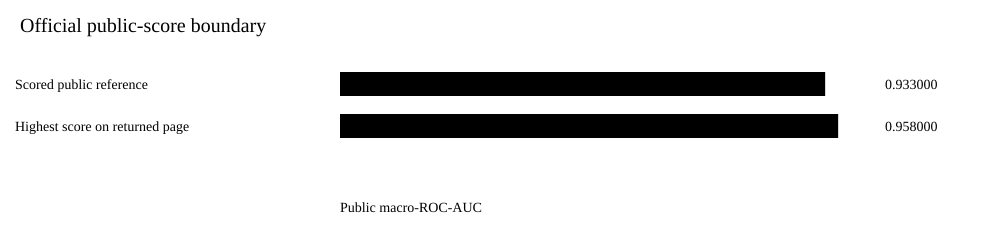

Comparable dated gap: 0.025
Candidate public score: None


In [2]:
L=D['leaderboard']
gap=leaderboard_gap(L['reference_public_auc'],L['highest_returned_page_auc'])
print(f'Comparable dated gap: {gap:.3f}')
print('Candidate public score:',L['candidate_public_auc'])

## 2. Deployment parity is an engineering result

Stage 31 required both actual checkpoints, a hermetic CPU shadow, and an offline Tesla T4 preview. The normalized error-to-tolerance ratios below are far below 1.0. This proves implementation fidelity; it does **not** prove higher AUC.

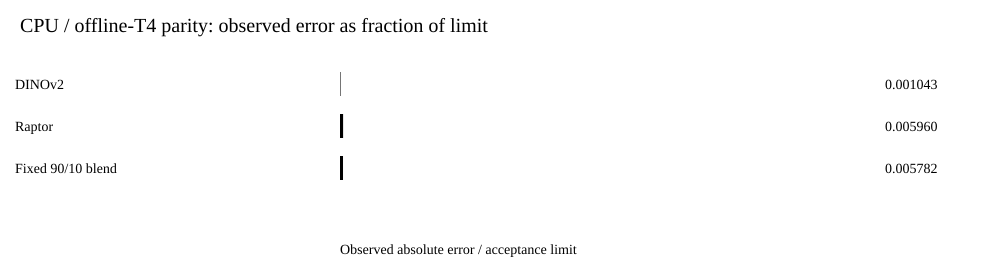

T4 visible-preview seconds: 39.871466409
DINOv2 max_abs_diff= 1.043081283569336e-06 fraction_of_limit= 0.001043
Raptor max_abs_diff= 5.960464477539062e-07 fraction_of_limit= 0.005960
Fixed 90/10 blend max_abs_diff= 5.781650542768801e-07 fraction_of_limit= 0.005782


In [3]:
P=D['deployment']
labels=['DINOv2','Raptor','Fixed 90/10 blend']
keys=['dino','raptor','blend']
ratios=[parity_ratio(P['cpu_gpu_max_abs_diff'][k],P['parity_tolerances'][k]) for k in keys]
print('T4 visible-preview seconds:',P['t4_preview_seconds'])
for lab,k,r in zip(labels,keys,ratios): print(lab,'max_abs_diff=',P['cpu_gpu_max_abs_diff'][k],'fraction_of_limit=',f'{r:.6f}')

## 3. The training-data ceiling is now visible

The accepted exact-window cache contains 960 of 4,407 studies. Stage 32 verified that the current official metadata matched the accepted AWS copy, but recent release work did not retrain a current full-data model. Completing the data contract is prerequisite work for credible grouped training.

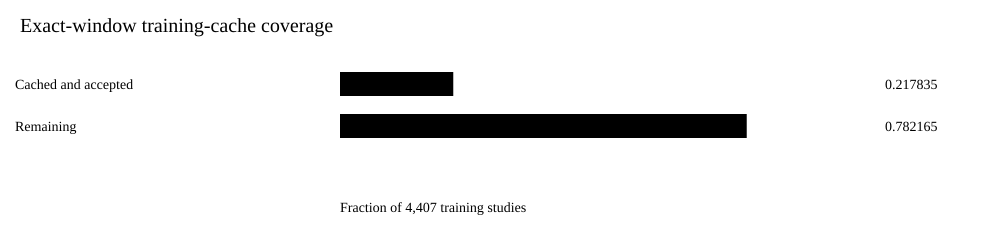

Cached studies: 960
Remaining studies: 3447
Coverage: 21.8%
Completed shards: 3 / 14
Current official metadata matches accepted AWS copy: True
Latest full-data training performed: False


In [4]:
T=D['training_data']
coverage=coverage_fraction(T['cached_studies'],T['train_studies'])
print('Cached studies:',T['cached_studies'])
print('Remaining studies:',T['remaining_studies'])
print(f'Coverage: {100*coverage:.1f}%')
print('Completed shards:',T['completed_shards'],'/',T['planned_shards'])
print('Current official metadata matches accepted AWS copy:',T['current_official_metadata_matches_aws'])
print('Latest full-data training performed:',T['latest_full_data_training_performed'])

## 4. Ranked ceiling-escape backlog

The backlog is ordered by expected information and score value rather than implementation convenience. Complete data and grouped OOF evidence come before larger backbones or more exposed-cohort blend tuning.

The next data-readiness gate is **prepared but not claimed as completed**: complete the exact-window cache, build the scanner-group catalog, freeze grouped folds with expert studies audit-only, and smoke-test the cache/fold join before a new fit.

In [5]:
for row in D['ranked_backlog']:
    print(f"{row['rank']}. {row['capability']} — {row['status']} — priority {row['priority']}")
print('Next gate:',D['next_gate']['name'])
print('Status:',D['next_gate']['status'])
print(D['next_gate']['note'])

1. Complete exact-window training cache — 960/4407 studies (21.8%) — priority 9.8
2. Scanner-grouped five-fold OOF baseline — not yet established — priority 9.5
3. Training-label lineage and soft-label audit — current public labels verified; full training lineage incomplete — priority 9.2
4. Geometry and slice-selection ablation — partially represented; no full-data matched OOF comparison — priority 8.6
5. Target-specific spatial / ROI modeling — not yet implemented for weak target families — priority 8.1
6. OOF heterogeneous ensemble — absent; prior blend weight came from exposed development cohorts — priority 7.9
Next gate: Complete exact-window cache and freeze scanner-grouped folds
Status: PREPARED_NOT_YET_COMPLETED
A corrected Stage-33 handoff exists outside GitHub, but this publication does not claim its execution or result.


## 5. Research judgment

**What improved:** the project can now prove deterministic model identity and numerical behavior across AWS CPU and an offline Kaggle T4 deployment.

**What did not improve yet:** no new current full-data weights were trained, and the new candidate's leaderboard score remained pending in the Stage-32 return.

**What changes next:** complete-data scanner-grouped training becomes the primary score-moving program. Future blend weights require fold-complete OOF predictions rather than exposed audit cohorts.

Raw MRI, report text, study identifiers, row-level predictions, weights, private logs, environments, and credentials remain outside this public repository.

In [6]:
assert D['stage32']['gates_passed']==8
assert D['stage32']['training_fits']==0
assert D['stage32']['submissions']==0
assert D['leaderboard']['candidate_public_auc'] is None
assert D['training_data']['latest_full_data_training_performed'] is False
print('RSNA_TRAINING_FRONTIER_PUBLICATION_COMPLETE')

RSNA_TRAINING_FRONTIER_PUBLICATION_COMPLETE
